In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm

import albumentations as A

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [3]:
root = Path("../../dataset/cropped_tumor_images")

benign_dir = root / "benign/images"
malignant_dir = root / "malignant/images"

print("Benign folder exists:", benign_dir.exists())
print("Malignant folder exists:", malignant_dir.exists())

Benign folder exists: True
Malignant folder exists: True


In [4]:
def collect_images(folder, class_name, class_id):
    rows = []
    for img_path in sorted(folder.glob("*.png")):
        if img_path.name.startswith("._"):
            continue
        rows.append({
            "image_path": str(img_path),
            "class_name": class_name,
            "label": class_id
        })
    return rows

records = []
records += collect_images(benign_dir, "benign", 0)
records += collect_images(malignant_dir, "malignant", 1)

clf_df = pd.DataFrame(records)
print("Total samples:", len(clf_df))
clf_df.head()

Total samples: 647


,image_path,class_name,label
0,../../dataset/cropped_tumor_images/benign/imag...,benign,0
1,../../dataset/cropped_tumor_images/benign/imag...,benign,0
2,../../dataset/cropped_tumor_images/benign/imag...,benign,0
3,../../dataset/cropped_tumor_images/benign/imag...,benign,0
4,../../dataset/cropped_tumor_images/benign/imag...,benign,0


class_name
benign       437
malignant    210
Name: count, dtype: int64


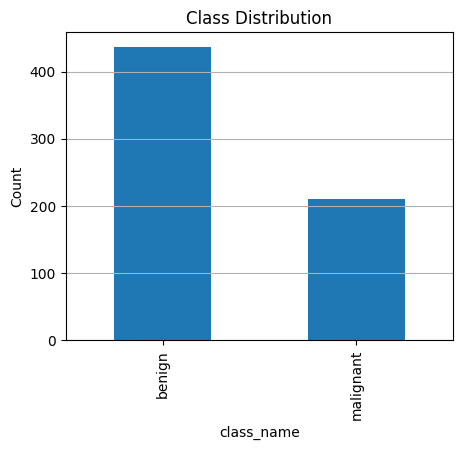

In [5]:
print(clf_df["class_name"].value_counts())

plt.figure(figsize=(5, 4))
clf_df["class_name"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

In [6]:
train_df, temp_df = train_test_split(
    clf_df,
    test_size=0.30,
    random_state=42,
    stratify=clf_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 452
Val: 97
Test: 98


In [7]:
train_aug = A.Compose([
    A.Resize(224, 224),
    A.Rotate(limit=10, p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=0.05, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(blur_limit=(3, 3), p=0.2),
])

val_aug = A.Compose([
    A.Resize(224, 224),
])

In [8]:
class BUSIClassificationDataset(Dataset):
    def __init__(self, df, augment=None):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not read image: {row['image_path']}")

        if self.augment is not None:
            img = self.augment(image=img)["image"]

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))   # HWC -> CHW

        label = row["label"]

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [9]:
train_ds = BUSIClassificationDataset(train_df, augment=train_aug)
val_ds   = BUSIClassificationDataset(val_df, augment=val_aug)
test_ds  = BUSIClassificationDataset(test_df, augment=val_aug)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

x, y = next(iter(train_loader))
print("Image batch shape:", x.shape)
print("Label batch shape:", y.shape)

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])


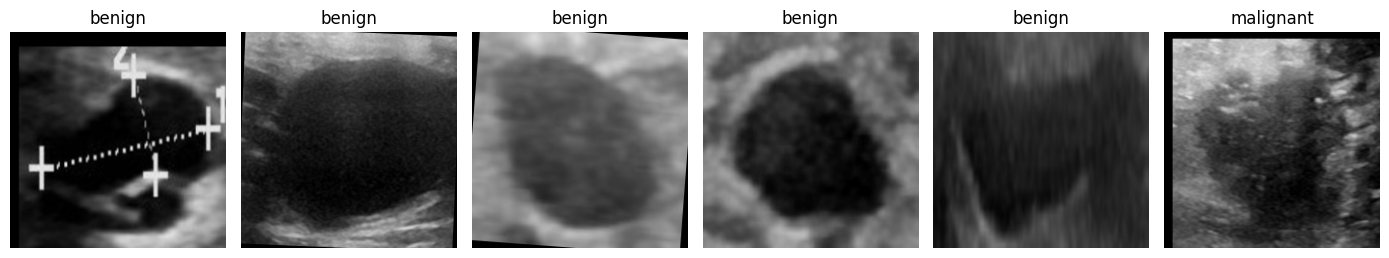

In [10]:
class_names = ["benign", "malignant"]

def show_batch(loader, n=6):
    images, labels = next(iter(loader))
    n = min(n, len(images))

    plt.figure(figsize=(14, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [61]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

In [62]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)